# Pipeline 1 — realçar primeiro

Etapas:

1. Ruído gaussiano (sigma 15, semente 42)
2. Equalização de histograma
3. Filtro Gaussiano 5x5 (sigma 1)
4. High-boost (k 1,5)

A pipeline 2 usa as mesmas técnicas na ordem inversa.

In [ ]:
import os
import subprocess
import sys

# Fora do repositório (Google Colab, notebook enviado sozinho) não existem as pastas
# src/ e data/: clona o repositório e entra em notebooks/ para os caminhos "../" funcionarem.
if not os.path.isdir("../src/pdi"):
    PASTA_REPO = os.path.abspath("trabalho-pdi-m1.2")
    if not os.path.isdir(PASTA_REPO):
        subprocess.run(["git", "clone", "https://github.com/mello745/trabalho-pdi-m1.2.git", PASTA_REPO], check=True)
    os.chdir(os.path.join(PASTA_REPO, "notebooks"))

sys.path.insert(0, "../src")

from pdi import pipeline
from pdi.gustavo import io_utils
from pdi.gustavo import operacoes_pontuais as op
from pdi.heloisa import ruido, suavizacao
from pdi.joao import agucamento, metricas

IMAGENS = {
    "ISIC_0014049": "../data/originais/ISIC_0014049.jpg",  # baixo contraste
    "ISIC_7236365": "../data/originais/ISIC_7236365.jpg",  # pelos densos
    "ISIC_0021531": "../data/originais/ISIC_0021531.jpg",  # bordas difusas
}

CONFIG_1 = [
    ("degradada",  lambda im: ruido.ruido_gaussiano(im, sigma=15, semente=42)),
    ("equalizada", lambda im: op.equalizar_histograma(im)),
    ("suavizada",  lambda im: suavizacao.filtro_gaussiano(im, tamanho=5, sigma=1.0)),
    ("agucada",    lambda im: agucamento.high_boost(im, tamanho=3, sigma=1.0, k=1.5)),
]

CONFIG = CONFIG_1

## 1. Execução nas 3 imagens

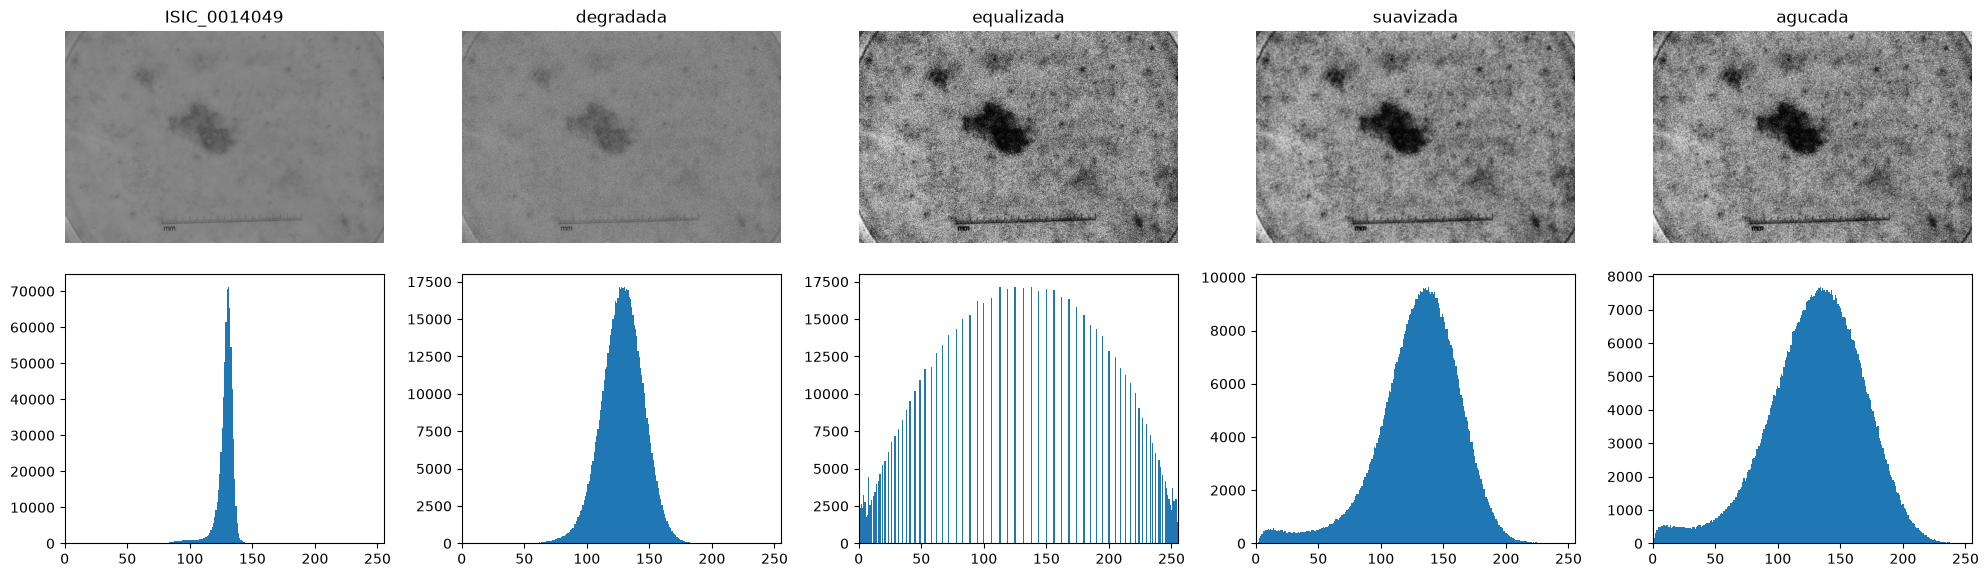

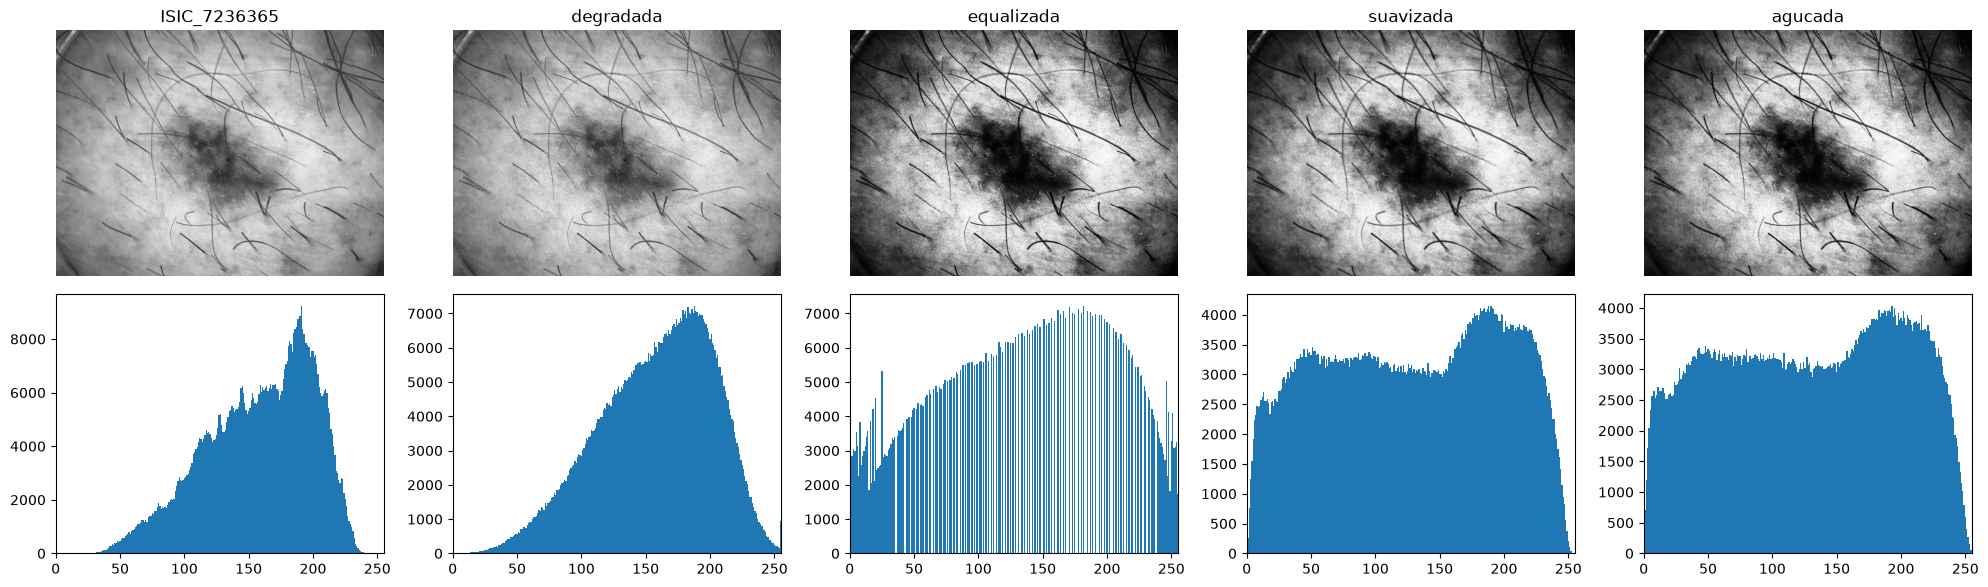

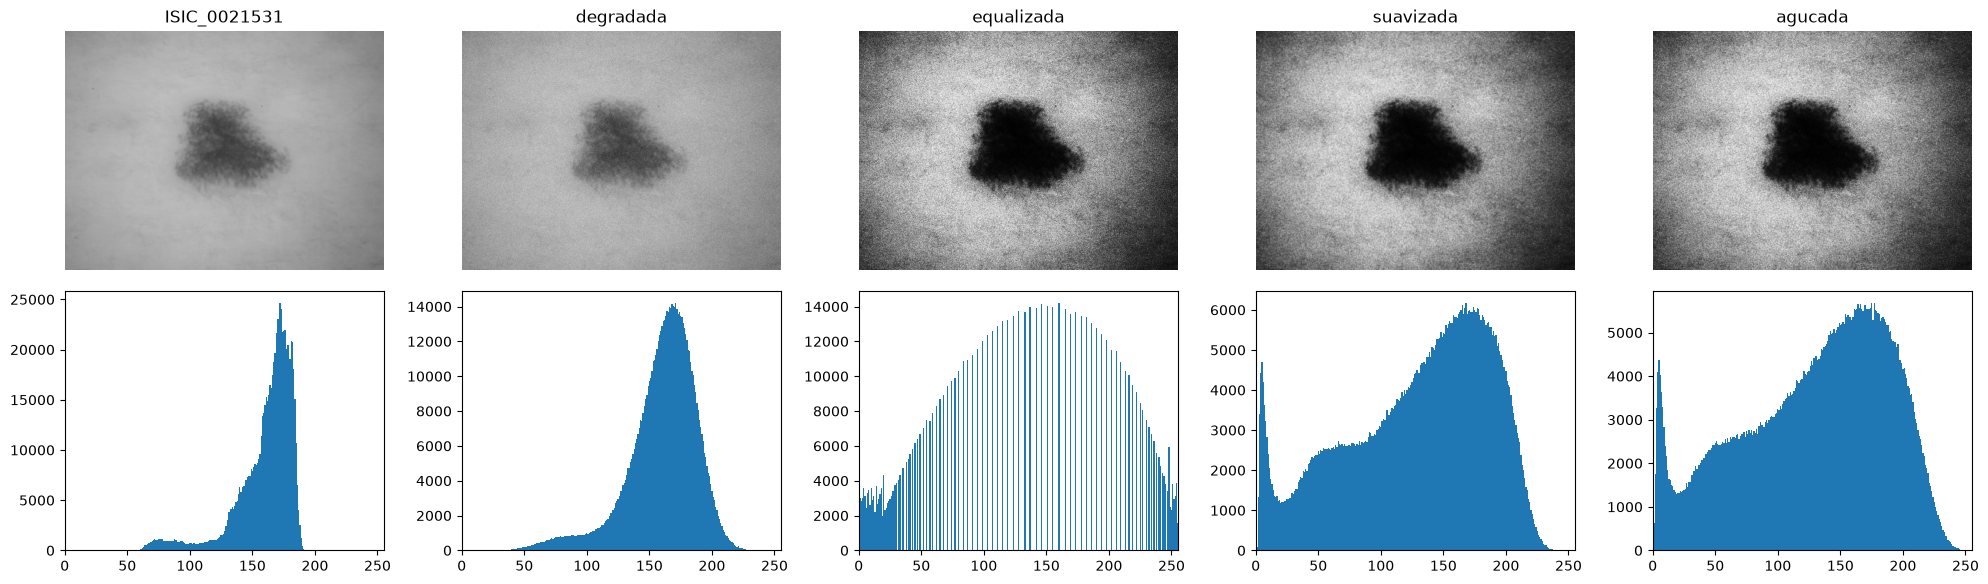

In [2]:
resultados = {}
for nome, caminho in IMAGENS.items():
    img = io_utils.carregar_cinza(caminho, largura_max=1024)
    resultados[nome] = pipeline.executar(img, CONFIG)
    io_utils.mostrar(pipeline.imagens(resultados[nome]),
                     [nome if e == "original" else e for e in pipeline.nomes(resultados[nome])])

## 2. Métricas (referência: original sem ruído)

In [3]:
for nome, res in resultados.items():
    original = res[0][1]
    print(nome)
    for etapa, im in res[1:]:
        print(f"  {etapa:<11} PSNR {metricas.psnr(original, im):6.2f} dB   SSIM {metricas.ssim(original, im):.3f}")

ISIC_0014049


  degradada   PSNR  24.60 dB   SSIM 0.240


  equalizada  PSNR  11.08 dB   SSIM 0.022


  suavizada   PSNR  19.11 dB   SSIM 0.205


  agucada     PSNR  17.51 dB   SSIM 0.119
ISIC_7236365


...

  agucada     PSNR  15.52 dB   SSIM 0.513
ISIC_0021531


  degradada   PSNR  24.60 dB   SSIM 0.232


  equalizada  PSNR  11.58 dB   SSIM 0.035


  suavizada   PSNR  14.41 dB   SSIM 0.276


  agucada     PSNR  14.10 dB   SSIM 0.168


## 3. Observações

Notebook demonstrativo: mostra cada estágio da pipeline 1 nas três imagens e as métricas de cada estágio.
A comparação com a pipeline 2 e a discussão dos resultados estão em [trabalho_m1.ipynb](trabalho_m1.ipynb).

## 4. Teste com imagem nova

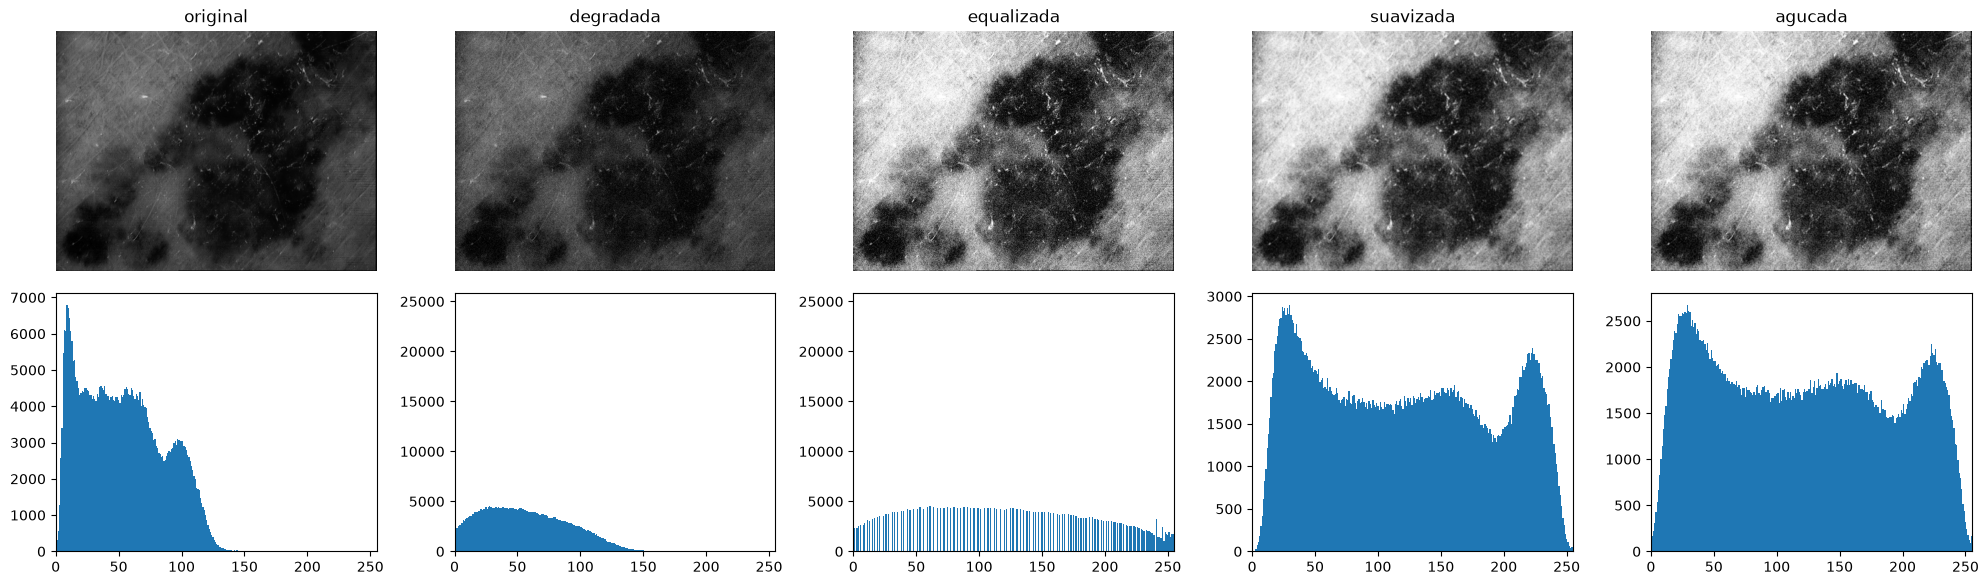

degradada   PSNR  24.94 dB   SSIM 0.397
equalizada  PSNR   9.61 dB   SSIM 0.143


suavizada   PSNR  10.25 dB   SSIM 0.456


agucada     PSNR  10.18 dB   SSIM 0.375


In [4]:
IMAGEM_TESTE = "../data/originais/ISIC_0112420.jpg"  # troque por qualquer imagem

img = io_utils.carregar_cinza(IMAGEM_TESTE, largura_max=1024)
res = pipeline.executar(img, CONFIG)
io_utils.mostrar(pipeline.imagens(res), pipeline.nomes(res))
for etapa, im in res[1:]:
    print(f"{etapa:<11} PSNR {metricas.psnr(img, im):6.2f} dB   SSIM {metricas.ssim(img, im):.3f}")